#Step 0 - Setup the learning environment

To begin, we import some library modules and functions that we will use.   

Numpy is a collection of math functions including various matrix operations - see http://www.numpy.org/.   Matplotlib is a 2D plotting library  - see https://matplotlib.org/.

In [1]:
"""
mlp_bp_ann.py

Backpropagation tutorial using a two layer ANN, without
the aid of additional NN libraries. 
This two-layer ANN has one layer of hidden nodes that allows the model to develop
non-linear functions

The program uses  Numpy for faster matrix operations and 
Matplotlib for plotting the training error per epoch

"""

from __future__ import print_function

import numpy as np
import matplotlib.pyplot as plt

print("The enviriment is ready.")

The enviriment is ready.


#Step 1 - Create the training data.
The data can be examples of any simple two variable boolean logic function such as OR, AND, or XOR.



In [2]:
# Define the function inputs and target output values: bias row, x1 row, x2 row
data_in = np.array([(1, 1, 1, 1), (0, 1, 0, 1), (0, 0, 1, 1)])
#target = np.array([0, 1, 1, 1])  # OR
#target = np.array([0, 0, 0, 1])  # AND
target = np.array([0, 1, 1, 0])  # XOR

print(data_in.T)
print(target)

[[1 0 0]
 [1 1 0]
 [1 0 1]
 [1 1 1]]
[0 1 1 0]


#Step 2 - Configure the neural network architecture 
Define a back-propagation neural network with one hidden layer of two nodes and one output node.  


In [3]:
# Set the learing parameters
learning_rate = 0.1
momemtum = 0.5
num_epochs = 20000

# Set the dimensions of the input, hidden, and output layers
size_in = 2
size_hidden = 100  # Can be anything - larger will take longer
size_out = target.ndim

# Set the seed value of the random number generator
random_seed = 2
np.random.seed(random_seed)

# Initialize the network weights, and place to store previous epoch weights
weight_out = np.random.rand(size_out, size_hidden + 1) - 0.5
weight_hidden = np.random.rand(size_hidden, size_in + 1) - 0.5

weight_hidden_prev = np.zeros(weight_hidden.shape)
weight_out_prev = np.zeros(weight_out.shape)

# Initialize a vector to store the train errors for each epoch
error_log = np.zeros([num_epochs])

print("Outout node initial weights:")
print(weight_out)
print("Hidden node initial weights:")
print(weight_hidden)

Outout node initial weights:
[[-6.40050979e-02 -4.74073768e-01  4.96624779e-02 -6.46776074e-02
  -7.96321979e-02 -1.69665179e-01 -2.95351366e-01  1.19270966e-01
  -2.00345326e-01 -2.33172725e-01  1.21133833e-01  2.91420943e-02
  -3.65420055e-01  1.35781213e-02 -3.15560134e-01  2.85335148e-01
   3.53975293e-01 -5.76316262e-03  3.46561485e-01 -4.20354523e-01
   5.24609012e-03 -4.34713496e-01 -7.18776724e-02 -4.03469084e-01
  -3.72840028e-01  9.67453090e-02 -2.73987999e-01 -3.93054316e-01
  -2.79693793e-01 -1.50173715e-01 -3.22125154e-02 -2.98256774e-01
   1.40406725e-01 -1.69301644e-02  5.23672002e-03 -1.13107349e-01
   2.93637454e-01  8.00041789e-02 -3.37701401e-01  2.00752347e-01
   4.64551080e-01  8.36117022e-06  3.89520064e-01 -1.58386347e-01
   6.71441276e-02 -7.24540367e-02 -6.32527370e-02  2.76559185e-01
   3.56041735e-02  4.53742227e-01  4.42081601e-02 -4.17905078e-01
  -1.33657598e-01  3.50850504e-01 -9.37249570e-02 -4.72797634e-01
  -2.52822761e-01 -4.32855629e-01  4.93852011e-

#Step 3 - Fit the data to the model
The model uses the mean squared error (MSE) loss function, which works well with the sigmoid activation output nodes. 
It uses the gradient descent weight update algorithm.


In [4]:
for i in range(0, num_epochs):

    # Compute the predicted output for the hidden layer, then adding bias
    predicted_h = 1 / (1 + np.exp(np.dot(-weight_hidden, data_in)))
    predicted_h = np.concatenate((np.ones([1, data_in.shape[1]]), predicted_h), axis=0)

    # Compute the output of network
    predicted_out = 1 / (1 + np.exp(np.dot(-weight_out, predicted_h)))

    # Compute the derivatives for the weight updates
    deriv_out = (predicted_out * (1 - predicted_out)) * (target - predicted_out)
    deriv_h = (predicted_h * (1 - predicted_h)) * (weight_out.T * deriv_out)

    # Compute the update to the input to hidden node weights
    deriv_weight_h = learning_rate * np.dot(
        data_in, deriv_h[1:].T).T + momemtum * weight_hidden_prev
    weight_hidden = weight_hidden + deriv_weight_h
    weight_hidden_prev = deriv_weight_h

    # Compute the update to the hidden to output node weights
    deriv_weight_out = learning_rate * np.dot(predicted_h, deriv_out.T).T 
    deriv_weight_out = deriv_weight_out + momemtum * weight_out_prev #add momentum
    weight_out = weight_out + deriv_weight_out 
    weight_out_prev = deriv_weight_out

    # Compute the error (loss) of the network for this epoch 
    predicted_out_err = 1 / (1 + np.exp(np.dot(-weight_out, np.concatenate(
        (np.ones([1, 4]), (1 / (1 + np.exp(np.dot(-weight_hidden, data_in)))))))))
    error_log[i] = 0.5 * ((predicted_out_err - target) ** 2).mean(axis=None)
    if (i % 50) == 0:
        # print('XOR bias momentum MSE: {0}'.format(error_log[i]))
        print("Iter: %d, MSE: %8.7f" % (i, error_log[i]))


Iter: 0, MSE: 0.1637446
Iter: 50, MSE: 0.1246639
Iter: 100, MSE: 0.1244358
Iter: 150, MSE: 0.1242368
Iter: 200, MSE: 0.1240375
Iter: 250, MSE: 0.1238254
Iter: 300, MSE: 0.1235927
Iter: 350, MSE: 0.1233327
Iter: 400, MSE: 0.1230377
Iter: 450, MSE: 0.1226984
Iter: 500, MSE: 0.1223029
Iter: 550, MSE: 0.1218359
Iter: 600, MSE: 0.1212773
Iter: 650, MSE: 0.1206008
Iter: 700, MSE: 0.1197721
Iter: 750, MSE: 0.1187462
Iter: 800, MSE: 0.1174649
Iter: 850, MSE: 0.1158545
Iter: 900, MSE: 0.1138227
Iter: 950, MSE: 0.1112578
Iter: 1000, MSE: 0.1080285
Iter: 1050, MSE: 0.1039878
Iter: 1100, MSE: 0.0989860
Iter: 1150, MSE: 0.0928990
Iter: 1200, MSE: 0.0856785
Iter: 1250, MSE: 0.0774196
Iter: 1300, MSE: 0.0684162
Iter: 1350, MSE: 0.0591516
Iter: 1400, MSE: 0.0501942
Iter: 1450, MSE: 0.0420371
Iter: 1500, MSE: 0.0349770
Iter: 1550, MSE: 0.0290936
Iter: 1600, MSE: 0.0243089
Iter: 1650, MSE: 0.0204671
Iter: 1700, MSE: 0.0173943
Iter: 1750, MSE: 0.0149313
Iter: 1800, MSE: 0.0129452
Iter: 1850, MSE: 0.01133

Iter: 15050, MSE: 0.0001491
Iter: 15100, MSE: 0.0001484
Iter: 15150, MSE: 0.0001478
Iter: 15200, MSE: 0.0001472
Iter: 15250, MSE: 0.0001465
Iter: 15300, MSE: 0.0001459
Iter: 15350, MSE: 0.0001453
Iter: 15400, MSE: 0.0001447
Iter: 15450, MSE: 0.0001441
Iter: 15500, MSE: 0.0001435
Iter: 15550, MSE: 0.0001429
Iter: 15600, MSE: 0.0001423
Iter: 15650, MSE: 0.0001417
Iter: 15700, MSE: 0.0001412
Iter: 15750, MSE: 0.0001406
Iter: 15800, MSE: 0.0001400
Iter: 15850, MSE: 0.0001394
Iter: 15900, MSE: 0.0001389
Iter: 15950, MSE: 0.0001383
Iter: 16000, MSE: 0.0001378
Iter: 16050, MSE: 0.0001372
Iter: 16100, MSE: 0.0001367
Iter: 16150, MSE: 0.0001361
Iter: 16200, MSE: 0.0001356
Iter: 16250, MSE: 0.0001351
Iter: 16300, MSE: 0.0001345
Iter: 16350, MSE: 0.0001340
Iter: 16400, MSE: 0.0001335
Iter: 16450, MSE: 0.0001330
Iter: 16500, MSE: 0.0001325
Iter: 16550, MSE: 0.0001320
Iter: 16600, MSE: 0.0001315
Iter: 16650, MSE: 0.0001310
Iter: 16700, MSE: 0.0001305
Iter: 16750, MSE: 0.0001300
Iter: 16800, MSE: 0.

#Step 4 - Evaluate the model on the training set and print the results.
And then plot the training error for each epoch through the data.

Target outputs: [0 1 1 0]
Predicted outputs: [[0.01257594 0.98555072 0.98562122 0.01607454]]


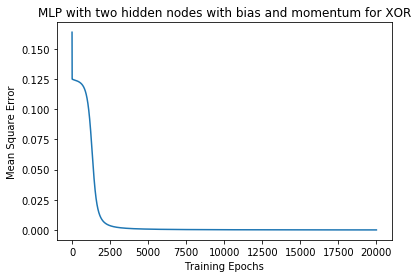

In [5]:
# Print the traget values and the networks predictions
print("Target outputs:", target)
print("Predicted outputs:", predicted_out)

# Set up the plot of the training error by epoch
plt.figure(4)
plt.xlabel('Training Epochs')
plt.ylabel('Mean Square Error')
plt.title('MLP with two hidden nodes with bias and momentum for XOR')
plt.plot(error_log)
plt.draw()

plt.show()  # keeping the plots alive until you close them